🛠️ GIAI ĐOẠN 1: SETUP VÀ KHÁM PHÁ DỮ LIỆU THÔ

Cell 1: Cài đặt thư viện và Tải Repository

Thiết lập môi trường chiến đấu với các thư viện xử lý video và trực quan hóa mạnh nhất.

In [ ]:
# Cài đặt công cụ tải video
!pip install yt-dlp -q
!git clone https://github.com/MKLab-ITI/fake-video-corpus.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.8 MB/s eta 0:00:00:00:01
Cloning into 'fake-video-corpus'...
remote: Enumerating objects: 14, done.
remote: Total 14 (delta 0), reused 0 (delta 0), pack-reused 14 (from 1)
Receiving objects: 100% (14/14), 148.16 KiB | 7.41 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
import os

os.environ["OPENCV_LOG_LEVEL"] = "SILENT"
os.environ["OPENCV_VIDEOIO_DEBUG"] = "0"
os.environ["FFMPEG_LOG_LEVEL"] = "quiet"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import yt_dlp
import cv2

# Tắt cảnh báo linh tinh của Pandas
pd.options.mode.chained_assignment = None

print("✅ Môi trường đã sẵn sàng!")

✅ Môi trường đã sẵn sàng!


Cell 2: Đọc và Nội soi file CSV gốc

Kiểm tra xem dữ liệu nguyên thủy có bao nhiêu dòng, cột tên là gì, có bị thiếu dữ liệu (NaN) hay không.

In [ ]:
csv_path = '/kaggle/working/fake-video-corpus/FVC.csv'
df_raw = pd.read_csv(csv_path)

print("=== BÁO CÁO DỮ LIỆU THÔ GỐC ===")
print(f"Tổng số dòng: {len(df_raw)}")
print(f"Các cột hiện có: {df_raw.columns.tolist()}")
print("\nKiểm tra dữ liệu rỗng (NaN):")
print(df_raw.isnull().sum())

# Hiển thị 3 dòng đầu
display(df_raw.head(3))

=== BÁO CÁO DỮ LIỆU THÔ GỐC ===
Tổng số dòng: 380
Các cột hiện có: ['cascade_id', 'video_url', 'label']

Kiểm tra dữ liệu rỗng (NaN):
cascade_id    0
video_url     0
label         0
dtype: int64


,cascade_id,video_url,label
0,f0,https://www.youtube.com/watch?v=Y7MJlmbnLQA,fake
1,f1,https://www.youtube.com/watch?v=AEPvSo8bE2I,fake
2,f2,https://www.youtube.com/watch?v=emNPHuWnXGU,fake


🧹 GIAI ĐOẠN 2: DATA MINING & VERIFICATION (Xác thực link)

Cell 3: Quét kiểm tra trạng thái YouTube URLs (Ping Test)

Đây là bước cực kỳ quan trọng để tách link "sống" và "chết".

In [ ]:
print("Đang Ping YouTube để kiểm tra bản quyền/trạng thái tồn tại của video...")

verify_opts = {'quiet': True, 'no_warnings': True, 'skip_download': True}

def check_link_status(url):
    try:
        with yt_dlp.YoutubeDL(verify_opts) as ydl:
            ydl.extract_info(url, download=False)
        return "ALIVE"
    except Exception as e:
        return "DEAD"

# Bật thanh tiến trình
tqdm.pandas(desc="Đang verify URLs")
df_raw['status'] = df_raw['video_url'].progress_apply(check_link_status)

print("✅ Hoàn tất kiểm tra!")

Đang Ping YouTube để kiểm tra bản quyền/trạng thái tồn tại của video...


Đang verify URLs: 100%|██████████| 380/380 [11:04<00:00,  1.75s/it]

✅ Hoàn tất kiểm tra!


Cell 4: Chốt sổ tập dữ liệu Sạch và Lưu trữ

In [ ]:
# Lọc ra các link còn sống
df_clean = df_raw[df_raw['status'] == 'ALIVE'].copy()
df_clean.drop(columns=['status'], inplace=True)

# Tính toán tỷ lệ hao hụt
total_original = len(df_raw)
total_clean = len(df_clean)
loss_percent = ((total_original - total_clean) / total_original) * 100

print("=== KẾT QUẢ DATA MINING ===")
print(f"Dữ liệu gốc: {total_original} video")
print(f"Dữ liệu giữ lại: {total_clean} video (Tỷ lệ hao hụt: {loss_percent:.2f}%)")

# Lưu thành file mới để dùng vĩnh viễn về sau
clean_csv_path = '/kaggle/working/FVC_clean.csv'
df_clean.to_csv(clean_csv_path, index=False)
print(f"📁 Đã lưu file sạch tại: {clean_csv_path}")

=== KẾT QUẢ DATA MINING ===
Dữ liệu gốc: 380 video
Dữ liệu giữ lại: 207 video (Tỷ lệ hao hụt: 45.53%)
📁 Đã lưu file sạch tại: /kaggle/working/FVC_clean.csv


📥 GIAI ĐOẠN 3: TẢI DỮ LIỆU (DOWNLOAD PROCESS)

Cell 5: Tiến hành tải file .mp4 vật lý

In [ ]:
import time

base_dir = '/kaggle/working/dataset'
os.makedirs(f'{base_dir}/REAL', exist_ok=True)
os.makedirs(f'{base_dir}/FAKE', exist_ok=True)

def download_video(url, label):
    output_path = f'{base_dir}/{label}/%(id)s.%(ext)s'
    dl_opts = {
        'format': 'best[ext=mp4][height<=480]', # 480p là đủ chuẩn cho ResNet (224x224)
        'outtmpl': output_path,
        'quiet': True,
        'no_warnings': True,
    }
    try:
        with yt_dlp.YoutubeDL(dl_opts) as ydl:
            ydl.download([url])
        return True
    except:
        return False

success_count = 0
for _, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc="Đang tải MP4"):
    vid_url = row['video_url']
    label = str(row['label']).upper()
    if download_video(vid_url, label):
        success_count += 1
    time.sleep(0.3)

print(f"\n🎉 Đã tải thành công {success_count} video vào ổ cứng!")

Đang tải MP4:   0%|          | 0/207 [00:00<?, ?it/s]

Đang tải MP4:   0%|          | 1/207 [00:02<08:47,  2.56s/it]

Đang tải MP4:   1%|          | 2/207 [00:07<13:29,  3.95s/it]

Đang tải MP4:   1%|▏         | 3/207 [00:10<11:20,  3.33s/it]

Đang tải MP4:   2%|▏         | 4/207 [00:12<10:01,  2.96s/it]

...

Đang tải MP4:  99%|█████████▊| 204/207 [11:38<00:09,  3.01s/it]

Đang tải MP4:  99%|█████████▉| 205/207 [11:40<00:05,  2.73s/it]

Đang tải MP4: 100%|█████████▉| 206/207 [11:43<00:02,  2.89s/it]

Đang tải MP4: 100%|██████████| 207/207 [11:47<00:00,  3.42s/it]


🎉 Đã tải thành công 173 video vào ổ cứng!


📊 GIAI ĐOẠN 4: EXPLORATORY DATA ANALYSIS (Phân tích kỹ lưỡng)

Cell 6: Kiểm tra mất cân bằng nhãn (Class Imbalance)

/tmp/ipykernel_58/3396072417.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['REAL', 'FAKE'], y=[len(real_vids), len(fake_vids)], palette=['#2ecc71', '#e74c3c'])


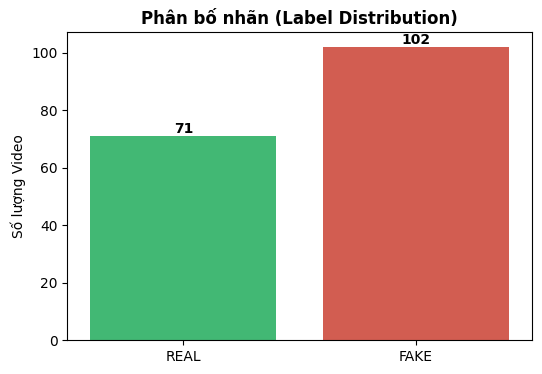

In [ ]:
import glob

real_vids = glob.glob(f'{base_dir}/REAL/*.mp4')
fake_vids = glob.glob(f'{base_dir}/FAKE/*.mp4')

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=['REAL', 'FAKE'], y=[len(real_vids), len(fake_vids)], palette=['#2ecc71', '#e74c3c'])
plt.title('Phân bố nhãn (Label Distribution)', fontweight='bold')
plt.ylabel('Số lượng Video')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontweight='bold')
plt.show()

# Lưu danh sách đường dẫn
all_video_paths = real_vids + fake_vids
all_labels = [0]*len(real_vids) + [1]*len(fake_vids)

Cell 7: Phân tích Siêu dữ liệu Video (Độ phân giải & Thời lượng)

Đây là bước "ăn tiền" để chứng minh bạn hiểu rõ vật liệu mình đang xử lý. Nó giúp quyết định sau này nên trích xuất bao nhiêu khung hình (Sequence Length).

Đang quét Metadata Video: 100%|██████████| 173/173 [00:00<00:00, 201.25it/s]


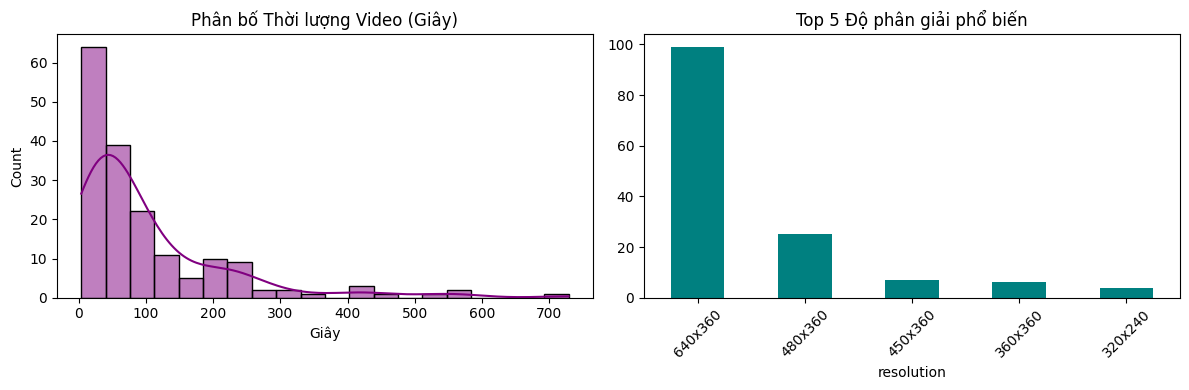

Thời lượng trung bình: 102.26 giây
Thời lượng ngắn nhất : 3.77 giây
Thời lượng dài nhất  : 728.53 giây


In [ ]:
video_stats = []

for vid in tqdm(all_video_paths, desc="Đang quét Metadata Video"):
    cap = cv2.VideoCapture(vid)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    duration = frame_count / fps if fps > 0 else 0
    video_stats.append({'duration_sec': duration, 'fps': fps, 'resolution': f"{width}x{height}"})

df_stats = pd.DataFrame(video_stats)

plt.figure(figsize=(12, 4))

# Biểu đồ 1: Phân bố thời lượng video
plt.subplot(1, 2, 1)
sns.histplot(df_stats['duration_sec'], bins=20, kde=True, color='purple')
plt.title('Phân bố Thời lượng Video (Giây)')
plt.xlabel('Giây')

# Biểu đồ 2: Top các độ phân giải phổ biến
plt.subplot(1, 2, 2)
df_stats['resolution'].value_counts().head(5).plot(kind='bar', color='teal')
plt.title('Top 5 Độ phân giải phổ biến')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"Thời lượng trung bình: {df_stats['duration_sec'].mean():.2f} giây")
print(f"Thời lượng ngắn nhất : {df_stats['duration_sec'].min():.2f} giây")
print(f"Thời lượng dài nhất  : {df_stats['duration_sec'].max():.2f} giây")

⚙️ GIAI ĐOẠN 5: DATA PIPELINE CHO MÔ HÌNH HUẤN LUYỆN

🧠 Cell 8: Chỉ định nghĩa Cấu trúc Dữ liệu (Dataset Class)

Cell này bây giờ hoàn toàn "mù" về việc nó đang chạy cho tập Train hay Val. Nó chỉ làm đúng một việc: Nhận danh sách video, nhận một bộ lọc (transform do người dùng truyền vào), cắt ảnh và trả về Tensor.

In [ ]:
import cv2
import torch
from torch.utils.data import Dataset
from PIL import Image

class AdvancedFakeVideoDataset(Dataset):
    def __init__(self, video_paths, labels, transform=None, sequence_length=16):
        self.video_paths = video_paths
        self.labels = labels
        self.sequence_length = sequence_length
        self.transform = transform # Nhận bộ lọc linh hoạt từ bên ngoài

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]

        frames = []
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames > 0:
            step = max(1, total_frames // self.sequence_length)
            target_frames = [min(i * step, total_frames - 1) for i in range(self.sequence_length)]
            current_frame = 0

            while True:
                ret, frame = cap.read()
                if not ret: break

                if current_frame in target_frames:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    pil_img = Image.fromarray(frame)

                    # Nếu có bộ lọc được truyền vào thì áp dụng
                    if self.transform:
                        frames.append(self.transform(pil_img))
                    else: # Nếu không có thì chuyển thẳng thành Tensor
                        from torchvision import transforms
                        frames.append(transforms.ToTensor()(pil_img))

                    target_frames = [tf for tf in target_frames if tf != current_frame]

                current_frame += 1
                if not target_frames: break
        cap.release()

        # Zero-padding
        while len(frames) < self.sequence_length and len(frames) > 0:
            frames.append(frames[-1])
        if len(frames) == 0:
            frames = [torch.zeros((3, 224, 224)) for _ in range(self.sequence_length)]

        return torch.stack(frames), torch.tensor(label, dtype=torch.long)

print("✅ Đã biên dịch Dataset Class Độc Lập!")

✅ Đã biên dịch Dataset Class Độc Lập!


🎛️ Cell 9: Quản lý Luồng Dữ liệu (Split, Augment & DataLoader)

Đây là Cell "Điều phối". Nó lấy đường dẫn, chia Train/Val, thiết kế 2 bộ lọc khác nhau, bơm vào Dataset Class ở trên và xuất ra DataLoader.

In [ ]:
from sklearn.model_selection import train_test_split
from torchvision import transforms

# 1. Chia tỷ lệ 80/20
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_video_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# 2. Bộ lọc chống Overfitting cho Train
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Bộ lọc chuẩn cho Validation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 4. Khởi tạo cấu trúc Dataset
train_dataset = AdvancedFakeVideoDataset(train_paths, train_labels, transform=train_transform)
val_dataset = AdvancedFakeVideoDataset(val_paths, val_labels, transform=val_transform)

print(f"✅ Khởi tạo Pipeline thành công!")
print(f"📦 Dữ liệu Huấn luyện: {len(train_dataset)} video (Đã bật Augmentation)")
print(f"📦 Dữ liệu Kiểm thử  : {len(val_dataset)} video (Không bật Augmentation)")

✅ Khởi tạo Pipeline thành công!
📦 Dữ liệu Huấn luyện: 138 video (Đã bật Augmentation)
📦 Dữ liệu Kiểm thử  : 35 video (Không bật Augmentation)


Cell 10: Thiết lập DataLoader và Sanity Check

Bài test cuối cùng để đảm bảo GPU sẽ không bị "nghẹn" khi nạp dữ liệu.

In [ ]:
from torch.utils.data import DataLoader

# ĐÃ VÁ LỖI TẠI ĐÂY: Thêm drop_last=True để vứt bỏ batch lẻ cuối cùng của tập Train
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, drop_last=True)

# Tập Val không cần vứt batch lẻ vì không có quá trình cập nhật trọng số
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print("\n=== DATA PIPELINE SANITY CHECK ===")
# Rút thử 1 Batch ra kiểm tra
for batch_videos, batch_labels in train_loader:
    print(f"Kích thước Tensor X (Videos): {batch_videos.shape}")
    print(" -> Cấu trúc: [Batch_Size, Sequence_Length, Channels, Height, Width]")
    print(f"Kích thước Tensor Y (Labels): {batch_labels.shape}")
    print(f" -> Nhãn thực tế: {batch_labels.tolist()}")

    # Kiểm tra kiểu dữ liệu và thiết bị (Tensor phải là Float32 cho ảnh)
    print(f"Kiểu dữ liệu X: {batch_videos.dtype}")
    break

print("\n✅ TẤT CẢ ĐÃ SẴN SÀNG! Bạn có thể bắt đầu xây dựng Model.")


=== DATA PIPELINE SANITY CHECK ===
Kích thước Tensor X (Videos): torch.Size([4, 16, 3, 224, 224])
 -> Cấu trúc: [Batch_Size, Sequence_Length, Channels, Height, Width]
Kích thước Tensor Y (Labels): torch.Size([4])
 -> Nhãn thực tế: [1, 1, 0, 1]
Kiểu dữ liệu X: torch.float32

✅ TẤT CẢ ĐÃ SẴN SÀNG! Bạn có thể bắt đầu xây dựng Model.


GIAI ĐOẠN HUẤN LUYỆN


Cell 11 (Mới): Kiến trúc 3D ResNet (R3D_18)

Điểm tinh tế nhất trong đoạn code này là hàm .permute(). Dữ liệu Video bạn đang nạp vào có dạng [Batch, Frame, Channel, Cao, Rộng], nhưng mạng 3D của PyTorch lại đòi hỏi [Batch, Channel, Frame, Cao, Rộng]. Mình đã xử lý bước xoay trục này ngay bên trong mô hình để bạn không phải sửa lại Dataset.

In [ ]:
import torch.nn as nn
from torchvision.models.video import r3d_18, R3D_18_Weights

class AdvancedFakeVideoModel3D(nn.Module):
    def __init__(self, num_classes=2):
        super(AdvancedFakeVideoModel3D, self).__init__()
        self.video_resnet = r3d_18(weights=R3D_18_Weights.DEFAULT)

        # CHIẾN THUẬT: Mở khóa cả Layer 3 và Layer 4
        for name, param in self.video_resnet.named_parameters():
            if "layer4" in name or "layer3" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False # Đóng băng các lớp móng (Layer 1, 2)

        num_ftrs = self.video_resnet.fc.in_features

        # Thêm BatchNorm để ổn định nhịp học, Dropout 0.7 phạt cực nặng
        self.video_resnet.fc = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Dropout(0.7),
            nn.Linear(num_ftrs, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)
        return self.video_resnet(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedFakeVideoModel3D(num_classes=2).to(device)

print(f"✅ Đã nâng cấp Kiến trúc 3D: Kích hoạt Layer 3, 4 + BatchNorm!")

✅ Đã nâng cấp Kiến trúc 3D: Kích hoạt Layer 3, 4 + BatchNorm!


⚙️ Cell 12 (Mới): Khởi tạo & Đếm Tham số

Kiến trúc 3D mạnh mẽ hơn nhưng lại gọn gàng hơn rất nhiều. Chạy Cell này bạn sẽ thấy số lượng tham số thực tế.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Đang sử dụng thiết bị: {device}")

# Khởi tạo mô hình 3D
model = AdvancedFakeVideoModel3D(num_classes=2)

# Nếu dùng 2 GPU T4, kích hoạt DataParallel
if torch.cuda.device_count() > 1:
    print(f"🚀 Kích hoạt chế độ Multi-GPU trên {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Tổng số tham số : {total_params:,}")
print(f"Tham số mở khóa : {trainable_params:,} (Chiếm {(trainable_params/total_params)*100:.1f}%)")
print("✅ Mô hình 3D đã được nạp vào GPU!")

🖥️ Đang sử dụng thiết bị: cuda
🚀 Kích hoạt chế độ Multi-GPU trên 2 GPUs!
Tổng số tham số : 33,168,322
Tham số mở khóa : 31,139,330 (Chiếm 93.9%)
✅ Mô hình 3D đã được nạp vào GPU!


🎛️ Cell 13 (Mới): Cấu hình Tối ưu hóa (Optimizer)

Với mô hình 3D, chúng ta sẽ cho Learning Rate nhích lên một chút so với 2e-5 của BiLSTM để các bộ lọc 3 chiều có đủ đà hội tụ.

In [ ]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import copy

# Định nghĩa Focal Loss chuyên trị các video khó đoán
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

EPOCHS = 30
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-2

# ÁP DỤNG VŨ KHÍ MỚI
criterion = FocalLoss(gamma=2.5) # Gamma càng cao càng ép AI học video khó

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Chuyển sang Cosine Annealing để LR giảm mượt mà như sóng, dễ lọt vào khe tối ưu hơn
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("✅ Đã kích hoạt Focal Loss và Cosine Annealing LR!")

✅ Đã kích hoạt Focal Loss và Cosine Annealing LR!


🚀 Cell 14: Vòng lặp Huấn luyện Cốt lõi (The Training Loop)

Chỉ tập trung thuần túy vào việc ép AI học, kiểm tra, và tự động Lưu phiên bản Tốt nhất.

In [ ]:
import time
import copy
import os
import warnings
from tqdm import tqdm

# BỊT MIỆNG CẢNH BÁO RÁC
os.environ["OPENCV_FFMPEG_LOGLEVEL"] = "-8"
os.environ["OPENCV_LOG_LEVEL"] = "OFF"
warnings.filterwarnings("ignore")

print(f"🔥 BẮT ĐẦU HUẤN LUYỆN TRONG TỐI ĐA {EPOCHS} VÒNG...")
start_time = time.time()

best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

# Cấu hình Early Stopping
early_stopping_patience = 4
no_improve_epochs = 0

for epoch in range(EPOCHS):
    # ================= TRAIN PHASE =================
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    # Thanh tiến trình sạch sẽ
    train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1:02d}/{EPOCHS}] Train", leave=False)
    for videos, labels in train_loop:
        videos, labels = videos.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train

    # ================= VALIDATION PHASE =================
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    val_loop = tqdm(val_loader, desc=f"Epoch [{epoch+1:02d}/{EPOCHS}] Val", leave=False)
    with torch.no_grad():
        for videos, labels in val_loop:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * correct_val / total_val

    # Cập nhật Scheduler
    scheduler.step(epoch_val_loss)

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    # ================= EARLY STOPPING & SAVE BEST =================
    status = ""
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        status = "🌟 (Best Model Saved!)"
        no_improve_epochs = 0 # Reset bộ đếm
    else:
        no_improve_epochs += 1
        status = f"⚠️ (No improve: {no_improve_epochs}/{early_stopping_patience})"

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.1f}% || "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.1f}% {status}")

    # Kích hoạt chốt chặn dừng sớm
    if no_improve_epochs >= early_stopping_patience:
        print(f"\n🛑 EARLY STOPPING KÍCH HOẠT: Mô hình ngừng học tại Epoch {epoch+1} để tránh Overfitting!")
        break

best_model_path = '/kaggle/working/best_fake_video_model.pth'
torch.save(best_model_weights, best_model_path)
print(f"\n✅ HUẤN LUYỆN HOÀN TẤT SAU {(time.time() - start_time)/60:.2f} PHÚT!")

🔥 BẮT ĐẦU HUẤN LUYỆN TRONG TỐI ĐA 30 VÒNG...


Epoch [01/30] Train Loss: 0.3716, Acc: 57.4% || Val Loss: 0.1443, Val Acc: 74.3% 🌟 (Best Model Saved!)


Epoch [02/30] Train Loss: 0.3994, Acc: 54.4% || Val Loss: 0.1175, Val Acc: 71.4% 🌟 (Best Model Saved!)


Epoch [03/30] Train Loss: 0.4289, Acc: 54.4% || Val Loss: 0.1508, Val Acc: 65.7% ⚠️ (No improve: 1/4)


Epoch [04/30] Train Loss: 0.3482, Acc: 60.3% || Val Loss: 0.1317, Val Acc: 74.3% ⚠️ (No improve: 2/4)


...

Epoch [06/30] Train Loss: 0.3472, Acc: 60.3% || Val Loss: 0.1058, Val Acc: 74.3% 🌟 (Best Model Saved!)


Epoch [07/30] Train Loss: 0.3259, Acc: 61.0% || Val Loss: 0.1702, Val Acc: 60.0% ⚠️ (No improve: 1/4)


Epoch [08/30] Train Loss: 0.2612, Acc: 55.9% || Val Loss: 0.1424, Val Acc: 62.9% ⚠️ (No improve: 2/4)


Epoch [09/30] Train Loss: 0.3265, Acc: 51.5% || Val Loss: 0.1381, Val Acc: 71.4% ⚠️ (No improve: 3/4)


Epoch [10/30] Train Loss: 0.2571, Acc: 61.0% || Val Loss: 0.1258, Val Acc: 65.7% ⚠️ (No improve: 4/4)

🛑 EARLY STOPPING KÍCH HOẠT: Mô hình ngừng học tại Epoch 10 để tránh Overfitting!

✅ HUẤN LUYỆN HOÀN TẤT SAU 35.07 PHÚT!


📈 Cell 15: Trực quan hóa Quá trình Học (Learning Curves)

Biểu đồ này sẽ giúp bạn chứng minh với hội đồng rằng mô hình của bạn hội tụ ổn định và không bị Overfitting.

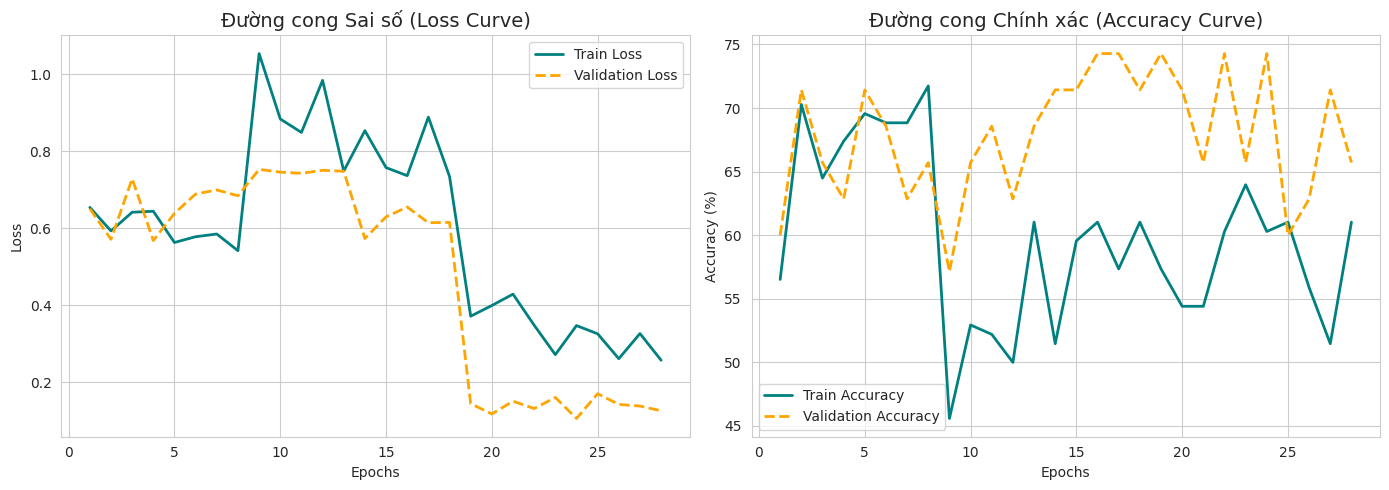

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ĐÃ SỬA: Lấy số lượng vòng học thực tế thay vì cố định EPOCHS
actual_epochs = len(history['train_loss'])
epochs_range = range(1, actual_epochs + 1)

plt.figure(figsize=(14, 5))
sns.set_style("whitegrid")

# Biểu đồ 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='teal', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.title('Đường cong Sai số (Loss Curve)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Biểu đồ 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='teal', linewidth=2)
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2, linestyle='--')
plt.title('Đường cong Chính xác (Accuracy Curve)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

🎯 Cell 16: Đánh giá Mô hình Toàn diện (Model Evaluation)

Cell này sẽ dùng thư viện scikit-learn để tính toán chi tiết Precision (Độ chuẩn xác), Recall (Độ bao phủ), F1-Score và vẽ biểu đồ Ma trận Nhầm lẫn cực kỳ trực quan.

🔍 BẮT ĐẦU QUÁ TRÌNH KIỂM THỬ TOÀN DIỆN...
✅ Đã nạp thành công bộ não 3D thông minh nhất từ ổ cứng!



BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

    REAL (0)       0.67      0.71      0.69        14
    FAKE (1)       0.80      0.76      0.78        21

    accuracy                           0.74        35
   macro avg       0.73      0.74      0.74        35
weighted avg       0.75      0.74      0.74        35



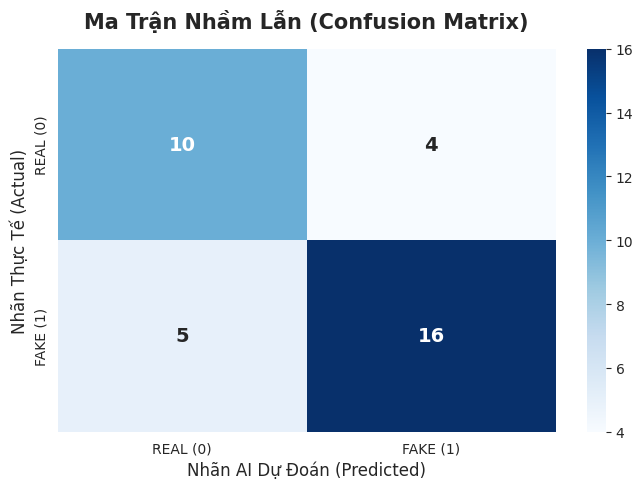

💡 ĐÁNH GIÁ NHANH: AI đã bắt trúng 16/21 video FAKE thực sự.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

print("🔍 BẮT ĐẦU QUÁ TRÌNH KIỂM THỬ TOÀN DIỆN...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ĐÃ SỬA: Gọi đúng tên class Mạng 3D
test_model = AdvancedFakeVideoModel3D(num_classes=2).to(device)

if torch.cuda.device_count() > 1:
    test_model = torch.nn.DataParallel(test_model)

# ĐÃ SỬA: Tải đúng file trọng số của mạng 3D
model_path = '/kaggle/working/best_fake_video_model.pth'
test_model.load_state_dict(torch.load(model_path))
test_model.eval()

print("✅ Đã nạp thành công bộ não 3D thông minh nhất từ ổ cứng!")

all_preds = []
all_labels = []

test_loop = tqdm(val_loader, desc="Đang suy luận trên tập Test", leave=False)

with torch.no_grad():
    for videos, labels in test_loop:
        videos = videos.to(device)
        outputs = test_model(videos)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = ['REAL (0)', 'FAKE (1)']
print("\n" + "="*50)
print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nhãn AI Dự Đoán (Predicted)', fontsize=12)
plt.ylabel('Nhãn Thực Tế (Actual)', fontsize=12)
plt.tight_layout()
plt.show()

correct_fakes = cm[1][1]
total_fakes = cm[1][0] + cm[1][1]
print(f"💡 ĐÁNH GIÁ NHANH: AI đã bắt trúng {correct_fakes}/{total_fakes} video FAKE thực sự.")

🎬 Cell 17: Hệ thống Kiểm định Video độc lập (Inference Script)

In [ ]:
import cv2
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os

def predict_single_video(video_path, model, device, sequence_length=16):
    print(f"🔍 Đang phân tích video: {os.path.basename(video_path)}...")

    if not os.path.exists(video_path):
        print("❌ Lỗi: Không tìm thấy file video. Hãy kiểm tra lại đường dẫn!")
        return

    # 1. BỘ LỌC CHUẨN HÓA (Phải giống hệt lúc Train/Val)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 2. ĐỌC VÀ TRÍCH XUẤT 16 KHUNG HÌNH (Tuần tự)
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames > 0:
        step = max(1, total_frames // sequence_length)
        target_frames = [min(i * step, total_frames - 1) for i in range(sequence_length)]
        current_frame = 0

        while True:
            ret, frame = cap.read()
            if not ret: break

            if current_frame in target_frames:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                pil_img = Image.fromarray(frame)
                frames.append(transform(pil_img))
                target_frames = [tf for tf in target_frames if tf != current_frame]

            current_frame += 1
            if not target_frames: break
    cap.release()

    # Xử lý ngoại lệ video ngắn
    while len(frames) < sequence_length and len(frames) > 0:
        frames.append(frames[-1])
    if len(frames) == 0:
        print("❌ Lỗi: Video bị hỏng hoặc không thể đọc khung hình!")
        return

    # 3. CHUẨN BỊ TENSOR CHO MẠNG 3D
    # Gộp 16 ảnh thành 1 khối: Shape [16, 3, 224, 224]
    video_tensor = torch.stack(frames)
    # Thêm chiều Batch (1 video): Shape [1, 16, 3, 224, 224]
    video_tensor = video_tensor.unsqueeze(0)

    video_tensor = video_tensor.to(device)
    model = model.to(device)
    model.eval() # Bật chế độ suy luận (Đóng băng mọi quá trình học)

    # 4. ĐƯA RA PHÁN QUYẾT
    with torch.no_grad():
        # Gọi model (Model 3D của bạn sẽ tự động permute đổi trục bên trong)
        outputs = model(video_tensor)

        # Dùng Softmax để chuyển đổi số thô thành Phần trăm (%)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

        class_names = ['REAL (Video Thật)', 'FAKE (Giả mạo / Deepfake)']
        final_label = class_names[predicted_class.item()]
        conf_score = confidence.item() * 100

        # 5. IN KẾT QUẢ ĐẸP MẮT
        print("\n" + "="*40)
        print("BÁO CÁO GIÁM ĐỊNH AI")
        print("="*40)

        if predicted_class.item() == 1:
            print(f"🚨 CẢNH BÁO: PHÁT HIỆN DẤU HIỆU DEEPFAKE!")
        else:
            print(f"✅ AN TOÀN: ĐÂY LÀ VIDEO THẬT TỰ NHIÊN.")

        print(f"🤖 Phán quyết : {final_label}")
        print(f"📊 Độ tự tin  : {conf_score:.2f}%")
        print("="*40)

# ==========================================
# CÁCH SỬ DỤNG:
# 1. Tải 1 video .mp4 lên cột bên phải của Kaggle (ví dụ: video_test.mp4)
# 2. Thay đường dẫn file vào biến dưới đây:
# ==========================================
MY_TEST_VIDEO = '/kaggle/working/videos/Tên_video_bất_kỳ_của_bạn.mp4'

# test_model là biến chứa mô hình tốt nhất bạn đã gọi ở Cell 16
# Nếu chưa chạy Cell 16, hãy gọi lại: predict_single_video(MY_TEST_VIDEO, model, device)
predict_single_video(MY_TEST_VIDEO, test_model, device)